# 01 — Limpieza y Validación de Datos
**Proyecto:** PredictRent — Predicción de precios de alquiler en Lima Metropolitana  
**Dataset:** `inmuebles_alquiler_clean.csv`  
**Objetivo:** Detectar y corregir problemas de calidad en el dataset antes del EDA y modelado.

---
## Índice
1. Carga del dataset
2. Inspección inicial
3. Análisis de nulos
4. Validación de reglas del diccionario de datos
5. Tratamiento de nulos
6. Detección de duplicados
7. Guardado del dataset limpio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Rutas del proyecto
RAW_PATH = '../data/raw/inmuebles_alquiler_clean.csv'
PROCESSED_PATH = '../data/processed/inmuebles_clean_v1.csv'

print('Librerías cargadas')

Librerías cargadas


---
## 1. Carga del dataset

In [2]:
df = pd.read_csv(RAW_PATH)
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')

Shape: (3348, 73)
Columnas: ['id_portal', 'url', 'fuente', 'precio_usd', 'area_final_m2', 'dormitorios', 'banos', 'cocheras', 'antiguedad_anios', 'amenities_count', 'tipo_propiedad', 'latitud', 'longitud', 'distrito_oficial', 'h3_index_8', 'dist_mar_km', 'dist_centro_km', 'area_por_dormitorio', 'mismatch_type', 'precision_geocoding', 'cantidad_denuncias', 'count_1km_supermercados', 'dist_nearest_m_supermercados', 'count_1km_farmacias', 'dist_nearest_m_farmacias', 'count_1km_colegios', 'dist_nearest_m_colegios', 'count_1km_hospitales', 'dist_nearest_m_hospitales', 'count_1km_bancos', 'dist_nearest_m_bancos', 'count_1km_universidades', 'dist_nearest_m_universidades', 'count_1km_parqueos', 'dist_nearest_m_parqueos', 'tiene_numero_de_pisos', 'tiene_ascensores', 'tiene_cocina', 'tiene_centros_comerciales_cercanos', 'tiene_piso_en_el_que_se_encuentra', 'tiene_seguridad', 'tiene_exteriores', 'tiene_reposteros_en_cocina', 'tiene_closet', 'tiene_recepcion', 'tiene_intercomunicador', 'tiene_cerc

---
## 2. Inspección inicial

In [3]:
df.head(3)

,id_portal,url,fuente,precio_usd,area_final_m2,dormitorios,banos,cocheras,antiguedad_anios,amenities_count,...,tiene_vista_al_mar,tiene_vista_parque,tiene_caseta_de_guardia,tiene_frente_a_parque,tiene_cerco_de_material_noble,tiene_portero_electrico,tiene_av_acceso_afirmada,tiene_duplex,tiene_frente_al_mar_primera_fila,tiene_jacuzzi
0,50441814,https://www.adondevivir.com/propiedades/clasif...,adondevivir,2000.0,210.0,3.0,2.0,2.0,12.0,19.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,50795573,https://www.adondevivir.com/propiedades/clasif...,adondevivir,650.0,60.0,1.0,1.0,1.0,3.0,13.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,51134377,https://www.adondevivir.com/propiedades/clasif...,adondevivir,2000.0,210.0,3.0,2.0,2.0,12.0,17.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3348 entries, 0 to 3347
Data columns (total 73 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id_portal                                3348 non-null   object 
 1   url                                      3348 non-null   object 
 2   fuente                                   3348 non-null   object 
 3   precio_usd                               3348 non-null   float64
 4   area_final_m2                            3348 non-null   float64
 5   dormitorios                              3314 non-null   float64
 6   banos                                    3326 non-null   float64
 7   cocheras                                 1294 non-null   float64
 8   antiguedad_anios                         1794 non-null   float64
 9   amenities_count                          3348 non-null   float64
 10  tipo_propiedad                           3348 no

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
precio_usd,3348.0,982.912846,748.445326,200.0,586.67,782.61,1100.0,7000.0
area_final_m2,3348.0,95.387097,67.040727,20.0,59.00,75.00,110.0,1180.0
dormitorios,3314.0,2.211829,0.979305,0.0,2.00,2.00,3.0,19.0
banos,3326.0,1.904690,3.755969,1.0,1.00,2.00,2.0,212.0
cocheras,1294.0,1.326893,0.591722,1.0,1.00,1.00,2.0,9.0
...,...,...,...,...,...,...,...,...
tiene_portero_electrico,2262.0,0.041114,0.198598,0.0,0.00,0.00,0.0,1.0
tiene_av_acceso_afirmada,2262.0,0.038462,0.192350,0.0,0.00,0.00,0.0,1.0
tiene_duplex,2262.0,0.038019,0.191286,0.0,0.00,0.00,0.0,1.0
tiene_frente_al_mar_primera_fila,2262.0,0.030062,0.170795,0.0,0.00,0.00,0.0,1.0


---
## 3. Análisis de nulos

**Decisión de diseño:** Según el diccionario de datos, existen dos tipos de nulos:
- **Nulos estructurales:** columnas `tiene_*` de Properati (~32.4%) → el portal no expone esa información, NaN ≠ 0.
- **Nulos de contenido:** `dormitorios`, `banos`, `cocheras`, `antiguedad_anios`, `area_por_dormitorio` → dato no informado por el anunciante.

In [6]:
# Mapa de nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'nulos': nulos, 'pct': nulos_pct}).query('nulos > 0').sort_values('pct', ascending=False)

print(f'Columnas con nulos: {len(nulos_df)}')
display(nulos_df)

Columnas con nulos: 50


,nulos,pct
cocheras,2054,61.35
antiguedad_anios,1554,46.42
tiene_cocina,1086,32.44
tiene_centros_comerciales_cercanos,1086,32.44
tiene_seguridad,1086,32.44
tiene_piso_en_el_que_se_encuentra,1086,32.44
tiene_numero_de_pisos,1086,32.44
tiene_ascensores,1086,32.44
tiene_tipo_de_cochera,1086,32.44
tiene_cerca_a_parque_a_menos_de_2_cdras,1086,32.44


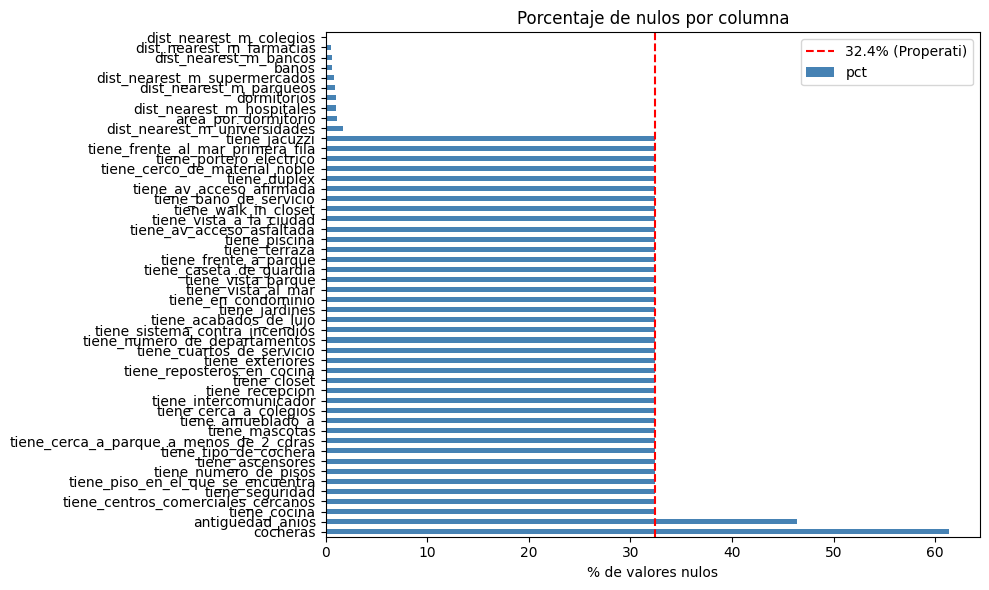

In [7]:
# Visualización de nulos
fig, ax = plt.subplots(figsize=(10, 6))
nulos_df['pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de nulos por columna')
ax.axvline(32.4, color='red', linestyle='--', label='32.4% (Properati)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/01_nulos.png', dpi=150)
plt.show()

In [8]:
# Confirmar que los nulos de amenities provienen de Properati
amenity_cols = [c for c in df.columns if c.startswith('tiene_')]
nulos_por_fuente = df.groupby('fuente')[amenity_cols[0]].apply(lambda x: x.isnull().sum())
print('Nulos en primera amenity por fuente:')
print(nulos_por_fuente)
print(f'\nTotal listings Properati: {(df["fuente"] == "properati").sum()}')

Nulos en primera amenity por fuente:
fuente
adondevivir       0
properati      1086
urbania           0
Name: tiene_numero_de_pisos, dtype: int64

Total listings Properati: 1086


---
## 4. Validación de reglas del diccionario de datos

El diccionario establece reglas de calidad para cada columna. Las validamos explícitamente.

In [9]:
# Regla: precio_usd > 200
invalidos_precio = df[df['precio_usd'] <= 200]
print(f'Filas con precio_usd <= 200: {len(invalidos_precio)}')

# Regla: area_final_m2 >= 20
invalidos_area = df[df['area_final_m2'] < 20]
print(f'Filas con area_final_m2 < 20: {len(invalidos_area)}')

# Regla: fuente pertenece a dominio cerrado
fuentes_validas = {'adondevivir', 'properati', 'urbania'}
invalidos_fuente = df[~df['fuente'].isin(fuentes_validas)]
print(f'Filas con fuente inválida: {len(invalidos_fuente)}')

# Regla: tipo_propiedad pertenece a dominio cerrado
tipos_validos = {'Departamento', 'Casa', 'Oficina', 'Local Comercial'}
df['tipo_propiedad'] = df['tipo_propiedad'].str.strip().str.title()  # Normalizar texto
invalidos_tipo = df[~df['tipo_propiedad'].isin(tipos_validos)]
print(f'Filas con tipo_propiedad inválido: {len(invalidos_tipo)}')
if len(invalidos_tipo) > 0:
    print('  Valores encontrados:', df['tipo_propiedad'].unique())

# Regla: latitud entre -12.5 y -11.5
invalidos_lat = df[(df['latitud'] < -12.5) | (df['latitud'] > -11.5)]
print(f'Filas con latitud fuera de Lima: {len(invalidos_lat)}')

# Regla: antiguedad_anios entre 0 y 100
invalidos_antig = df[(df['antiguedad_anios'] < 0) | (df['antiguedad_anios'] > 100)].dropna()
print(f'Filas con antiguedad_anios fuera de rango [0,100]: {len(invalidos_antig)}')

Filas con precio_usd <= 200: 6
Filas con area_final_m2 < 20: 0
Filas con fuente inválida: 0
Filas con tipo_propiedad inválido: 0
Filas con latitud fuera de Lima: 0
Filas con antiguedad_anios fuera de rango [0,100]: 0


In [10]:
# Regla: mismatch_type pertenece a dominio cerrado
mismatch_validos = {'ninguno', 'frontera', 'fraude'}
invalidos_mismatch = df[~df['mismatch_type'].isin(mismatch_validos)]
print(f'Filas con mismatch_type inválido: {len(invalidos_mismatch)}')
print('Distribución mismatch_type:')
print(df['mismatch_type'].value_counts())

Filas con mismatch_type inválido: 0
Distribución mismatch_type:
mismatch_type
ninguno     2893
frontera     394
fraude        61
Name: count, dtype: int64


---
## 5. Tratamiento de nulos

### 5.1 Columnas numéricas de contenido

**Estrategia:** Imputación por mediana agrupada (más robusta que la media ante outliers). Se usa `distrito_oficial` + `tipo_propiedad` como grupo.

In [11]:
df_clean = df.copy()

# Imputar antiguedad_anios por mediana agrupada
df_clean['antiguedad_anios'] = df_clean.groupby(['distrito_oficial', 'tipo_propiedad'])['antiguedad_anios'] \
    .transform(lambda x: x.fillna(x.median()))

# Si aún quedan nulos (grupos sin suficiente data), imputar con mediana global
mediana_global_antig = df_clean['antiguedad_anios'].median()
df_clean['antiguedad_anios'] = df_clean['antiguedad_anios'].fillna(mediana_global_antig)

print(f'Nulos en antiguedad_anios después de imputación: {df_clean["antiguedad_anios"].isnull().sum()}')

Nulos en antiguedad_anios después de imputación: 0


In [12]:
# --- Imputación de dormitorios y baños ---
# Valores imposibles: null para que la imputación los trate
BANOS_MAX_RAZONABLE = 20
DORM_MAX_RAZONABLE  = 20

df_clean.loc[df_clean['banos'] > BANOS_MAX_RAZONABLE, 'banos'] = np.nan
df_clean.loc[df_clean['dormitorios'] > DORM_MAX_RAZONABLE, 'dormitorios'] = np.nan

print(f'Nulos generados en banos:       {df_clean["banos"].isnull().sum()}')
print(f'Nulos generados en dormitorios: {df_clean["dormitorios"].isnull().sum()}')

Nulos generados en banos:       24
Nulos generados en dormitorios: 34


In [13]:
# --- Imputación de dormitorios y baños ---
# Imputar por tipo_propiedad + rango de área (bins).
# Crear bins de área basados en cuartiles (robusto ante outliers)
bins_area = [0, 50, 80, 120, 200, np.inf]
labels_area = ['0-50m2', '51-80m2', '81-120m2', '121-200m2', '200+m2']
df_clean['rango_area_bin'] = pd.cut(
    df_clean['area_final_m2'],
    bins=bins_area,
    labels=labels_area
)

# Mostrar la tabla de medianas resultante para validar la decisión
print('Mediana de dormitorios por tipo_propiedad + rango_area:')
print(df_clean.groupby(['tipo_propiedad', 'rango_area_bin'])['dormitorios']
      .median().to_string())
print()

for col in ['dormitorios', 'banos']:
    # Nivel 1: imputar por tipo_propiedad + rango_area_bin
    df_clean[col] = df_clean.groupby(
        ['tipo_propiedad', 'rango_area_bin']
    )[col].transform(lambda x: x.fillna(x.median()))

    # Nivel 2: si aún hay nulos (grupos sin datos suficientes),
    # imputar por tipo_propiedad solo
    aun_nulos = df_clean[col].isnull().sum()
    if aun_nulos > 0:
        df_clean[col] = df_clean.groupby('tipo_propiedad')[col] \
            .transform(lambda x: x.fillna(x.median()))

    # Nivel 3: mediana global
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    print(f'Nulos en {col} después de imputación: {df_clean[col].isnull().sum()}')

# Eliminar columna auxiliar de bins
df_clean.drop(columns=['rango_area_bin'], inplace=True)

# cocheras: NaN = no informado (distinto a 0). Creamos flag binaria
df_clean['cocheras_informadas'] = df_clean['cocheras'].notna().astype(int)
df_clean['cocheras'] = df_clean['cocheras'].fillna(0)
print(f'Flag cocheras_informadas creada. Nulos en cocheras: {df_clean["cocheras"].isnull().sum()}')

Mediana de dormitorios por tipo_propiedad + rango_area:
tipo_propiedad  rango_area_bin
Casa            0-50m2            NaN
                51-80m2           NaN
                81-120m2          9.0
                121-200m2         5.0
                200+m2            5.0
Departamento    0-50m2            1.0
                51-80m2           2.0
                81-120m2          3.0
                121-200m2         3.0
                200+m2            3.0

Nulos en dormitorios después de imputación: 0
Nulos en banos después de imputación: 0
Flag cocheras_informadas creada. Nulos en cocheras: 0


In [14]:
# Recalcular area_por_dormitorio con datos imputados
# Creamos una flag binaria 'es_estudio' que el modelo usará como señal de que se trata de una unidad sin dormitorios. 
# Para area_por_dormitorio, imputamos con el área total (todo el espacio es el 'dormitorio')
df_clean['es_estudio'] = (df_clean['dormitorios'] == 0).astype(int)

df_clean['area_por_dormitorio'] = np.where(
    df_clean['dormitorios'] > 0,
    df_clean['area_final_m2'] / df_clean['dormitorios'],
    df_clean['area_final_m2']   # Para estudios: el área completa es el espacio habitable
)

print(f'Nulos en area_por_dormitorio: {df_clean["area_por_dormitorio"].isnull().sum()}')
print(f'Flag es_estudio creada: {df_clean["es_estudio"].sum()} estudios/monoambientes identificados')
print()
print('Perfil de los estudios identificados:')
print(df_clean[df_clean['es_estudio'] == 1][['area_final_m2', 'dormitorios', 'precio_usd']].describe().round(1))

Nulos en area_por_dormitorio: 0
Flag es_estudio creada: 5 estudios/monoambientes identificados

Perfil de los estudios identificados:
       area_final_m2  dormitorios  precio_usd
count            5.0          5.0         5.0
mean            33.0          0.0       390.8
std             10.4          0.0       109.8
min             20.0          0.0       260.0
25%             25.0          0.0       282.0
50%             35.0          0.0       463.8
75%             40.0          0.0       470.0
max             45.0          0.0       478.3


### 5.2 Amenities binarias (columnas `tiene_*`)

**Decisión justificada:** Las columnas `tiene_*` son NaN en Properati porque ese portal no expone amenities estructuradas. Imputar con 0 sería incorrecto semánticamente (0 = "no tiene" vs NaN = "no se sabe"). 

**Estrategia:** Imputamos con 0 para Properati y creamos una feature `es_properati` para que el modelo aprenda este sesgo de portal. En AdondeVivir y Urbania, donde hay NaN puntual, imputamos con 0 (significa genuinamente que no tiene esa amenity).

In [15]:
amenity_cols = [c for c in df_clean.columns if c.startswith('tiene_')]

# Imputar todas las amenities con 0 (con la flag es_properati el modelo aprende el sesgo)
df_clean[amenity_cols] = df_clean[amenity_cols].fillna(0)

print(f'Nulos en amenities después de imputación: {df_clean[amenity_cols].isnull().sum().sum()}')

Nulos en amenities después de imputación: 0


### 5.3 Variables `dist_nearest_m_*` — nulos con significado geográfico

**Análisis:** Cada nulo en `dist_nearest_m_*` coincide exactamente con `count_1km_* = 0`.
Esto significa que no hay ningún POI de ese tipo dentro de 1km del inmueble —
el nulo no es un dato faltante sino la consecuencia directa de ausencia geográfica.

Los distritos más afectados son La Molina, Punta Hermosa, Carabayllo y Lurín:
zonas periféricas o residenciales con menor densidad de servicios.

**Opciones consideradas:**
- Imputar con mediana global → mentiría al modelo: le diría que hay un
  supermercado a 400m cuando en realidad no hay ninguno a menos de 1km.
- Imputar con un valor grande fijo (ej. 9999m) → arbitrario y puede
  distorsionar el escalado.
- **(Opción elegida) Imputar con un valor centinela = distancia de referencia del percentil 95
  del dataset** → indica 'muy lejos' de forma coherente con la distribución
  real. Además, `count_1km_*` ya captura la ausencia con valor 0, por lo que
  el modelo tiene dos señales complementarias.

In [16]:
### 5.3 dist_nearest_m_*
dist_cols = [c for c in df_clean.columns if c.startswith('dist_nearest_m_')]

print('Imputación con centinela P95 por columna:')
for col in dist_cols:
    n_nulos = df_clean[col].isnull().sum()
    if n_nulos > 0:
        # Centinela = P95 de los valores existentes (representa 'muy lejos')
        centinela = df_clean[col].quantile(0.95)
        df_clean[col] = df_clean[col].fillna(centinela)
        print(f'  {col:<35} nulos={n_nulos:>3}  centinela={centinela:>8.0f}m')

print(f'\nNulos en dist_nearest_* restantes: {df_clean[dist_cols].isnull().sum().sum()}')

Imputación con centinela P95 por columna:
  dist_nearest_m_supermercados        nulos= 27  centinela=     571m
  dist_nearest_m_farmacias            nulos= 19  centinela=     490m
  dist_nearest_m_colegios             nulos=  6  centinela=     346m
  dist_nearest_m_hospitales           nulos= 35  centinela=     527m
  dist_nearest_m_bancos               nulos= 20  centinela=     536m
  dist_nearest_m_universidades        nulos= 56  centinela=     662m
  dist_nearest_m_parqueos             nulos= 31  centinela=     566m

Nulos en dist_nearest_* restantes: 0


---
## 6. Detección de duplicados

In [17]:
# Duplicados exactos
dup_exactos = df_clean.duplicated().sum()
print(f'Duplicados exactos: {dup_exactos}')

# Duplicados por id_portal + fuente
dup_id = df_clean.duplicated(subset=['id_portal', 'fuente']).sum()
print(f'Duplicados por id_portal + fuente: {dup_id}')

if dup_id > 0:
    df_clean = df_clean.drop_duplicates(subset=['id_portal', 'fuente'], keep='first')
    print(f'Shape después de eliminar duplicados: {df_clean.shape}')

Duplicados exactos: 0
Duplicados por id_portal + fuente: 0


---
## 7. Resumen final y guardado

In [18]:
# Verificación final de nulos
nulos_finales = df_clean.isnull().sum()
print('Nulos restantes:')
print(nulos_finales[nulos_finales > 0])

print(f'\nShape original:  {df.shape}')
print(f'Shape limpio:    {df_clean.shape}')
print(f'Nueva columna:   cocheras_informadas')

Nulos restantes:
Series([], dtype: int64)

Shape original:  (3348, 73)
Shape limpio:    (3348, 75)
Nueva columna:   cocheras_informadas


In [19]:
# Guardar dataset limpio
df_clean.to_csv(PROCESSED_PATH, index=False)
print(f' Dataset limpio guardado en: {PROCESSED_PATH}')

 Dataset limpio guardado en: ../data/processed/inmuebles_clean_v1.csv
